### Configure environment

In [1]:
import chi, os, time, datetime
from chi import lease
from chi import server
from chi import context
from chi import hardware
from chi import network
from chi import ssh

In this section, we configure the Chameleon Python client.

For this experiment, we’re going to use the KVM@TACC site, which we indicate below.

We also need to specify the name of the Chameleon “project” that this experiment is part of. The project name will have the format “CHI-XXXXXX”, where the last part is a 6-digit number, and you can find it on your [user dashboard](https://chameleoncloud.org/user/dashboard/).

In the cell below, select the correct project ID, then run the cell.

In [2]:
context.version = "1.0" 
context.choose_project()
context.choose_site(default="KVM@TACC")
username = os.getenv('USER') # all exp resources will have this suffix

# configure openstacksdk for actions unsupported by python-chi
os_conn = chi.clients.connection()


### Configuration for federated learning experiment

In [3]:
username = os.getenv('USER')

node_conf = [
 {'name': "server",   'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-00",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-01",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-02",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-03",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-04",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-05",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-06",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-07",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-08",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-09",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}
]
net_conf = [
     {"name": "net0", "subnet": "10.0.0.0/24", 
      "nodes": [
     {"name": "server",   "addr": "10.0.0.1"}, 
     {"name": "client-00",   "addr": "10.0.0.100"}, 
     {"name": "client-01",   "addr": "10.0.0.101"}, 
     {"name": "client-02",   "addr": "10.0.0.102"}, 
     {"name": "client-03",   "addr": "10.0.0.103"}, 
     {"name": "client-04",   "addr": "10.0.0.104"}, 
     {"name": "client-05",   "addr": "10.0.0.105"}, 
     {"name": "client-06",   "addr": "10.0.0.106"}, 
     {"name": "client-07",   "addr": "10.0.0.107"}, 
     {"name": "client-08",   "addr": "10.0.0.108"}, 
     {"name": "client-09",   "addr": "10.0.0.109"}
     ] }
]

### Configure resources

Now, we will prepare the VMs and network links that our experiment requires.

First, we will prepare a “public” network that we will use for SSH access to our VMs -

In [4]:
public_net = os_conn.network.create_network(name="public_net_" + username)
public_net_id = public_net.get("id")
public_subnet = os_conn.network.create_subnet(
    name="public_subnet_" + username,
    network_id=public_net.get("id"),
    ip_version='4',
    cidr="192.168.10.0/24",
    gateway_ip="192.168.10.1",
    is_dhcp_enabled = True
)

Next, we will prepare the “experiment” networks -

In [5]:
nets = []
net_ids = []
subnets = []
for n in net_conf:
    exp_net = os_conn.network.create_network(name="exp_" + n['name']  + '_' + username)
    exp_net_id = exp_net.get("id")
    os_conn.network.update_network(exp_net, is_port_security_enabled=False)
    exp_subnet = os_conn.network.create_subnet(
        name="exp_subnet_" + n['name']  + '_' + username,
        network_id=exp_net.get("id"),
        ip_version='4',
        cidr=n['subnet'],
        gateway_ip=None,
        is_dhcp_enabled = False
    )
    nets.append(exp_net)
    net_ids.append(exp_net_id)
    subnets.append(exp_subnet)

Now we create the VMs -

In [6]:
servers = []
server_ids = []
for i, n in enumerate(node_conf, start=10):

    # reserve the node
    l = lease.Lease(n['name'] + "_" + username, duration=datetime.timedelta(hours=n.get('duration', 6)))
    l.add_flavor_reservation(id=chi.server.get_flavor_id(n['flavor']), amount=1)
    l.submit(idempotent=True)
    flavor_uuid = l.get_reserved_flavors()[0].id
    
    image_uuid = os_conn.image.find_image(n['image']).id

    # find out details of exp interface(s)
    nics = [{'net-id': chi.network.get_network_id( "exp_" + net['name']  + '_' + username ), 'v4-fixed-ip': node['addr']} for net in net_conf for node in net['nodes'] if node['name']==n['name']]
    # also include a public network interface
    nics.insert(0, {"net-id": public_net_id, "v4-fixed-ip":"192.168.10." + str(i)})
    server = chi.server.create_server(
        server_name=n['name'] + "_" + username,
        image_id=image_uuid,
        flavor_id=flavor_uuid,
        nics=nics
    )
    servers.append(server)
    server_ids.append(chi.server.get_server(n['name'] + "_" + username).id)

Waiting for lease to start...


Lease server_sea9106_nyu_edu has reached status active


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Waiting for lease to start...


Lease client-00_sea9106_nyu_edu has reached status active


...

Lease client-08_sea9106_nyu_edu has reached status active


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Waiting for lease to start...


Lease client-09_sea9106_nyu_edu has reached status active


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


We wait for all servers to come up before we proceed -

In [7]:
for server_id in server_ids:
    chi.server.wait_for_active(server_id)

Next, we will set up SSH access to the VMs.

First, we will make sure the “public” network is connected to the Internet. Then, we will configure it to permit SSH access on port 22 for each port connected to this network.

In [8]:
# connect them to the Internet on the "public" network (e.g. for software installation)
router = chi.network.create_router('inet_router_' + username, gw_network_name='public')
chi.network.add_subnet_to_router(router.get("id"), public_subnet.get("id"))

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


{'id': '251ea069-895c-42fa-8f5e-cdf177490b94',
 'tenant_id': '287158fd03da48e48eb0d2682f38fcc9',
 'port_id': '141528a1-28c0-43b9-8be5-69786fd5cc0f',
 'network_id': '695ae78b-83ee-464d-b2bb-cd7541029e30',
 'subnet_id': 'f145274e-7b79-44ef-b121-7808692eb685',
 'subnet_ids': ['f145274e-7b79-44ef-b121-7808692eb685']}

In [9]:
# prepare SSH access on the servers
# WARNING: this relies on undocumented behavior of associate_floating_ip 
# that it associates the IP with the first port on the server
server_ips = []
for server_id in server_ids:
    ip = chi.server.associate_floating_ip(server_id)
    server_ips.append(ip)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The py

Note: The following cells assumes that a security group named “Allow SSH” already exists in your project, and is configured to allow SSH access on port 22. If you have done the “Hello, Chameleon” experiment then you already have this security group.

In [10]:
security_group_id = os_conn.get_security_group("Allow SSH").id
for port in chi.network.list_ports(): 
    if port['port_security_enabled'] and port['network_id']==public_net.get("id"):
        os_conn.network.update_port(port['id'], security_groups=[security_group_id])

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


In [11]:
for ip in server_ips:
    chi.server.wait_for_tcp(ip, port=22)

Finally, we need to configure our resources, including software package installation and network configuration.

In [12]:
server_remotes = [chi.ssh.Remote(ip) for ip in server_ips]

In [13]:
# configure an IP address on each port that is supposed to have one
for port in chi.network.list_ports():
    if port['network_id'] in net_ids:
        i = server_ids.index(port['device_id'])
        j = net_ids.index(port['network_id'])
        port_conf =  [item for item in net_conf[j]['nodes'] if item['name'] == node_conf[i]['name'] ][0]
        if port_conf['addr']:
            server_remotes[i].run( "sudo ip addr flush dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )
            cmd_prefix = "sudo ip addr add " + port_conf['addr'] + "/" + net_conf[j]['subnet'].split("/")[1] 
            server_remotes[i].run( cmd_prefix + " dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )
        else:
            server_remotes[i].run( "sudo ip addr flush dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.27.139: b'318996e58d6c554e8e35b51f08ed7b8a'
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.27.29: b'9130b1987cc23297105ce05c0af9306c'
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.26.254: b'fa02bf3c75c35523d1d6898597e0936b'
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.25.68: b'52eaf459202e4305abae8ac238c8e534'
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.27.10: b'f69216481dd3847e5

In [14]:
for i, n in enumerate(node_conf):
    remote = server_remotes[i]
    # enable forwarding
    remote.run(f"sudo sysctl -w net.ipv4.ip_forward=1") 
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=192.168.0.0/16")
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=172.16.0.0/12")
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=10.0.0.0/8")
    # configure static routes
    for r in route_conf: 
        if n['name'] in r['nodes']:
            remote.run(f"sudo ip route add " + r['addr'] + " via " + r['gw']) 

net.ipv4.ip_forward = 1


FirewallD is not running


UnexpectedExit: Encountered a bad command exit code!

Command: 'sudo firewall-cmd --zone=trusted --add-source=192.168.0.0/16'

Exit code: 252

Stdout: already printed

Stderr: already printed



In [15]:
for i, n in enumerate(node_conf):
    # install packages
    if len(n['packages']):
            remote = server_remotes[i]
            remote.run(f"sudo apt update; sudo apt -y install " + " ".join(n['packages'])) 

In [16]:
# prepare a "hosts" file that has names and addresses of every node
hosts_txt = [ "%s\t%s" % ( n['addr'], n['name'] ) for net in net_conf  for n in net['nodes'] if type(n) is dict and n['addr']]
for remote in server_remotes:
    for h in hosts_txt:
        remote.run("echo %s | sudo tee -a /etc/hosts > /dev/null" % h)

In [17]:
# turn segment offload off
for port in chi.network.list_ports():
    if port['network_id'] in net_ids:
        i = server_ids.index(port['device_id'])
        j = net_ids.index(port['network_id'])
        for offload in ["gro", "gso", "tso"]:
            server_remotes[i].run( "sudo ethtool -K $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}') " + offload + " off" )

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


### Draw the network topology

The following cells will draw the network topology, for your reference.

In [18]:
!pip install networkx

In [19]:
nodes = [ (n['name'], {'color': 'pink'}) for n in net_conf ] + [(n['name'], {'color': 'lightblue'}) for n in node_conf ]
edges = [(net['name'], node['name'], 
          {'label': node['addr'] + '/' + net['subnet'].split("/")[1] }) if node['addr'] else (net['name'], node['name']) for net in net_conf for node in net['nodes'] ]

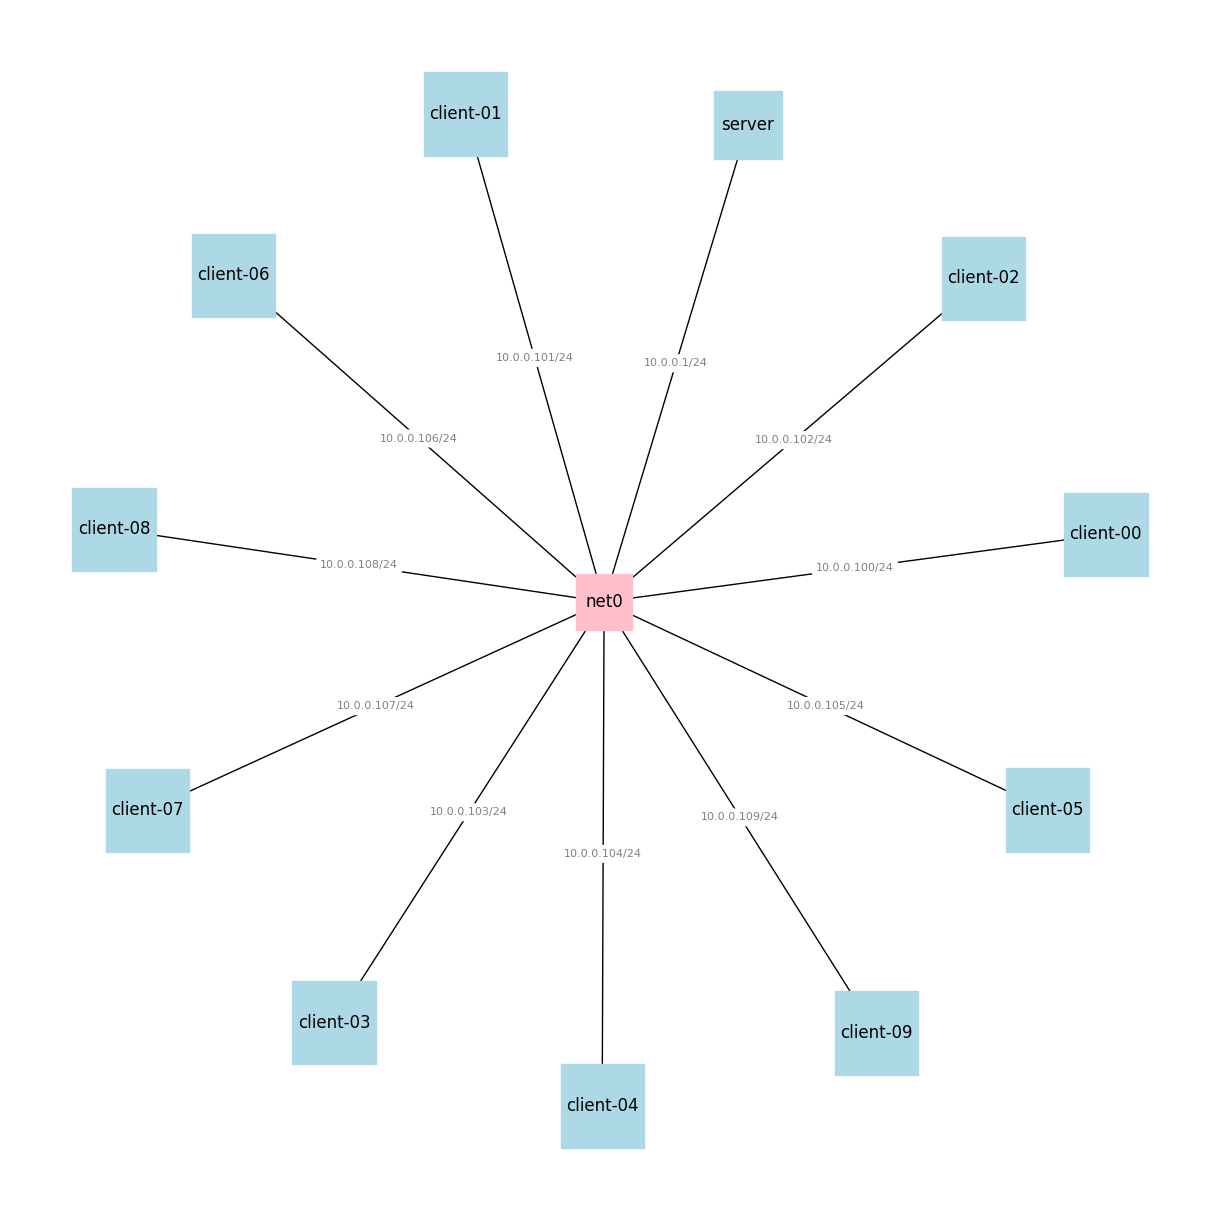

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
plt.figure(figsize=(len(nodes),len(nodes)))
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw(G, pos, node_shape='s',  
        node_color=[n[1]['color'] for n in nodes], 
        node_size=[len(n[0])*400 for n in nodes],  
        with_labels=True);
nx.draw_networkx_edge_labels(G,pos,
                             edge_labels=nx.get_edge_attributes(G,'label'),
                             font_color='gray',  font_size=8, rotate=False);

### Log in to resources

At this point, we should be able to log in to our resources over SSH! Run the following cell, and observe the output - you will see an SSH command for each of the nodes in your topology.

In [21]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
slice_info = [{'Name': n['name'], 'SSH command': "ssh cc@" + server_ips[i] } for i, n in enumerate(node_conf)]
pd.DataFrame(slice_info).set_index('Name')

,SSH command
Name,
server,ssh cc@129.114.25.68
client-00,ssh cc@129.114.27.234
client-01,ssh cc@129.114.27.237
client-02,ssh cc@129.114.27.139
client-03,ssh cc@129.114.26.169
client-04,ssh cc@129.114.24.9
client-05,ssh cc@129.114.26.84
client-06,ssh cc@129.114.26.254
client-07,ssh cc@129.114.27.29


Now, you can open an SSH session on any of the nodes as follows:

-   In Jupyter, from the menu bar, use File \> New \> Terminal to open a new terminal.
-   Copy an SSH command from the output above, and paste it into the terminal.
-   You can repeat this process (open several terminals) to start a session on each node. Each terminal session will have a tab in the Jupyter environment, so that you can easily switch between them.

Alternatively, you can use your local terminal to log on to each node, if you prefer. (On your local terminal, you may need to also specify your key path as part of the SSH command, using the `-i` argument followed by the path to your private key.)

## Other setup

In [22]:
for remote in server_remotes:
    remote.run("git clone https://github.com/Sabrinaaddo07/federated-chi")

Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...
Cloning into 'federated-chi'...


In [24]:
for remote in server_remotes:
    remote.run("sudo apt update; sudo apt -y install python3-pip")

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1030 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Components [180 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 c-n-f Metadata [17.4 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [1655 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Components [388 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 c-n-f Metadata [34.7 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [1110 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 c-n-f Metadata [456 B]
Get:13 http://ar

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  python3-wheel
The following NEW packages will be installed:
  python3-pip python3-wheel
0 upgraded, 2 newly installed, 0 to remove and 51 not upgraded.
Need to get 1373 kB of archives.
After this operation, 7270 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 python3-wheel all 0.42.0-2 [53.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 python3-pip all 24.0+dfsg-1ubuntu1.3 [1320 kB]


debconf: unable to initialize frontend: Dialog
debconf: (Dialog frontend will not work on a dumb terminal, an emacs shell buffer, or without a controlling terminal.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


Fetched 1373 kB in 0s (10.2 MB/s)
Selecting previously unselected package python3-wheel.
(Reading database ... 94180 files and directories currently installed.)
Preparing to unpack .../python3-wheel_0.42.0-2_all.deb ...
Unpacking python3-wheel (0.42.0-2) ...
Selecting previously unselected package python3-pip.
Preparing to unpack .../python3-pip_24.0+dfsg-1ubuntu1.3_all.deb ...
Unpacking python3-pip (24.0+dfsg-1ubuntu1.3) ...
Setting up python3-wheel (0.42.0-2) ...
Setting up python3-pip (24.0+dfsg-1ubuntu1.3) ...
Processing triggers for man-db (2.12.0-4build2) ...


debconf: unable to initialize frontend: Dialog
debconf: (Dialog frontend will not work on a dumb terminal, an emacs shell buffer, or without a controlling terminal.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype

Running kernel seems to be up-to-date.

No services need to be restarted.

No containers need to be restarted.

No user sessions are running outdated binaries.

No VM guests are running outdated hypervisor (qemu) binaries on this host.




...

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [777 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/main amd64 Components [44.8 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 http://security.ubuntu.com/ubuntu noble-security/main amd64 c-n-f Metadata [11.5 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1169 kB]
Get:7 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Components [76.2 kB]
Get:8 http://security.ubuntu.com/ubuntu noble-security/universe amd64 c-n-f Metadata [23.9 kB]
Get:9 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1048 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Components [212 B]
Get:11 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 c-n-f Metadata [444 B]
Get:12 http://security.ubuntu.com/ubuntu noble-security

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  python3-wheel
The following NEW packages will be installed:
  python3-pip python3-wheel
0 upgraded, 2 newly installed, 0 to remove and 51 not upgraded.
Need to get 1373 kB of archives.
After this operation, 7270 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 python3-wheel all 0.42.0-2 [53.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 python3-pip all 24.0+dfsg-1ubuntu1.3 [1320 kB]


debconf: unable to initialize frontend: Dialog
debconf: (Dialog frontend will not work on a dumb terminal, an emacs shell buffer, or without a controlling terminal.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


Fetched 1373 kB in 0s (8350 kB/s)
Selecting previously unselected package python3-wheel.
(Reading database ... 94180 files and directories currently installed.)
Preparing to unpack .../python3-wheel_0.42.0-2_all.deb ...
Unpacking python3-wheel (0.42.0-2) ...
Selecting previously unselected package python3-pip.
Preparing to unpack .../python3-pip_24.0+dfsg-1ubuntu1.3_all.deb ...
Unpacking python3-pip (24.0+dfsg-1ubuntu1.3) ...
Setting up python3-wheel (0.42.0-2) ...
Setting up python3-pip (24.0+dfsg-1ubuntu1.3) ...
Processing triggers for man-db (2.12.0-4build2) ...


debconf: unable to initialize frontend: Dialog
debconf: (Dialog frontend will not work on a dumb terminal, an emacs shell buffer, or without a controlling terminal.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype

Running kernel seems to be up-to-date.

No services need to be restarted.

No containers need to be restarted.

No user sessions are running outdated binaries.

No VM guests are running outdated hypervisor (qemu) binaries on this host.


In [26]:
for remote in server_remotes:
    remote.run("cd federated-chi; python3 -m venv .venv; source .venv/bin/activate; python3 -m pip install -r requirements.txt")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [33]:
fl_client_ips = [server_ips[i] for i, n in enumerate(node_conf) if n['name'] != "server"]
fl_server_ips = [server_ips[i] for i, n in enumerate(node_conf) if n['name'] == "server"]

In [35]:
fl_client_remotes = [chi.ssh.Remote(ip) for ip in fl_client_ips]
fl_server_remotes = [chi.ssh.Remote(ip) for ip in fl_server_ips]

In [37]:
for remote in fl_server_remotes:
    remote.run("cd federated-chi; python3 -m venv .venv; source .venv/bin/activate; cd model_dropout_experiment; python3 server.py &")

  MODEL DROPOUT EXPERIMENT
  8 clients  |  dropout_rate=0.0

  Open new terminals and run:
    python3 client.py --cid 0 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 1 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 2 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 3 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 4 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 5 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 6 --num_clients 8 --dropout_rate 0.0
    python3 client.py --cid 7 --num_clients 8 --dropout_rate 0.0

  Server listening on 127.0.0.1:8080
  Waiting for 8 clients...



Port in server address 127.0.0.1:8080 is already in use.


In [ ]:
for i, remote in enumerate(fl_client_remotes):
    remote.run("cd federated-chi; python3 -m venv .venv; source .venv/bin/activate; ")

### Delete resources

When you finish your experiment, you should delete your resources! The following cells deletes all the resources in this experiment, freeing them for other experimenters.

In [ ]:
# delete the nodes
server_ids = [chi.server.get_server_id(n['name'] + "_" + username) for n in node_conf]
server_ips = [d['addr'] for s in server_ids for d in chi.server.show_server(s).addresses['public_net_' + username] if d['OS-EXT-IPS:type']=='floating']
for server_id in server_ids:
    chi.server.delete_server(server_id)

In [ ]:
# release the floating IP addresses used for SSH
for server_ip in server_ips:
    ip_details = chi.network.get_floating_ip(server_ip)
    chi.neutron().delete_floatingip(ip_details["id"])

In [ ]:
# delete the router used for public Internet access
router = chi.network.get_router("inet_router_" + username)
public_subnet = chi.network.get_subnet("public_subnet_" + username)
public_net = chi.network.get_network("public_net_" + username)
chi.network.remove_subnet_from_router(router.get("id"), public_subnet.get("id"))
chi.network.delete_router(router.get("id"))

In [ ]:
# delete the public network
chi.network.delete_subnet(public_subnet.get('id'))
chi.network.delete_network(public_net.get("id"))

In [ ]:
# delete the experiment networks
subnets = [chi.network.get_subnet("exp_subnet_" + n['name']  + '_' + username) for n in net_conf]
nets    = [chi.network.get_network("exp_" + n['name']  + '_' + username) for n in net_conf]
for subnet, net in zip(subnets, nets):
    chi.network.delete_subnet(subnet.get('id'))
    chi.network.delete_network(net.get('id'))